# MelodyMatch-V2 — Class Imbalance Analysis

This notebook analyzes experiments designed to address the severe class imbalance in FMA Medium.

Experiments:

- Smoothed class weights
- SpecAugment
- Mixup
- Focal Loss
- Balanced Sampling
- Decoupled Training

The original CNN is included as the reference model.

Metrics:

- Accuracy
- Balanced Accuracy
- Macro-F1
- Weighted-F1

No model training is performed in this notebook.
All results are loaded from completed experiments.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "results").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"

In [4]:
model_files = {
    "CNN": "cnn_baseline.csv",
    "Smoothed Weights": "cnn_smoothed_weights_comparison.csv",
    "SpecAugment": "cnn_specaugment.csv",
    "Mixup": "cnn_mixup.csv",
    "Balanced Sampling": "cnn_balanced_sampling.csv",
    "Decoupled Training": "cnn_decoupled.csv",
}

In [5]:
imbalance_results = {}

for model_name, filename in model_files.items():
    path = METRICS_DIR / filename

    if not path.exists():
        print(f"Missing: {path}")
        continue

    imbalance_results[model_name] = pd.read_csv(path)

print("Loaded experiments:")

for model_name in imbalance_results:
    print("-", model_name)

Loaded experiments:
- CNN
- Smoothed Weights
- SpecAugment
- Mixup
- Balanced Sampling
- Decoupled Training


In [6]:
for model_name, df in imbalance_results.items():
    print(f"\n{model_name}")
    print(df.columns.tolist())
    display(df)


CNN
['split', 'loss', 'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']


,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,train,0.927073,0.664439,0.737287,0.591847,0.682237
1,validation,1.390619,0.642971,0.504557,0.460108,0.661304
2,test,1.470634,0.606143,0.515804,0.452737,0.624294



Smoothed Weights
['model', 'alpha', 'parameters', 'best_epoch', 'best_val_macro_f1', 'train_loss', 'train_accuracy', 'train_balanced_accuracy', 'train_macro_f1', 'train_weighted_f1', 'val_loss', 'val_accuracy', 'val_balanced_accuracy', 'val_macro_f1', 'val_weighted_f1', 'test_loss', 'test_accuracy', 'test_balanced_accuracy', 'test_macro_f1', 'test_weighted_f1', 'runtime_minutes']


,model,alpha,parameters,best_epoch,best_val_macro_f1,train_loss,train_accuracy,train_balanced_accuracy,train_macro_f1,train_weighted_f1,...,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,runtime_minutes
0,CNN_SmoothedWeights_alpha_0.25,0.25,392912,9,0.456440,1.130829,0.686344,0.480100,0.467883,0.663906,...,0.681310,0.464398,0.456440,0.653843,1.296364,0.638025,0.429589,0.409850,0.605415,31.032901
1,CNN_SmoothedWeights_alpha_0.50,0.50,392912,12,0.460924,1.184994,0.661324,0.589825,0.505394,0.670965,...,0.663738,0.508715,0.460924,0.664947,1.401215,0.623639,0.501457,0.442139,0.626389,39.212313
2,CNN_SmoothedWeights_alpha_0.75,0.75,392912,12,0.457785,1.196266,0.663284,0.622057,0.519536,0.672185,...,0.667732,0.510786,0.457785,0.669743,1.478564,0.623639,0.509092,0.441475,0.625382,40.526949
3,CNN_SmoothedWeights_alpha_1.00,1.00,392912,25,0.456938,1.001352,0.656300,0.715536,0.553423,0.671846,...,0.647764,0.496933,0.456938,0.662022,1.494638,0.602644,0.506185,0.447359,0.616541,61.197778



SpecAugment
['model', 'parameters', 'best_epoch', 'best_val_macro_f1', 'freq_mask_param', 'time_mask_param', 'augmentation_probability', 'train_loss', 'train_accuracy', 'train_balanced_accuracy', 'train_macro_f1', 'train_weighted_f1', 'val_loss', 'val_accuracy', 'val_balanced_accuracy', 'val_macro_f1', 'val_weighted_f1', 'test_loss', 'test_accuracy', 'test_balanced_accuracy', 'test_macro_f1', 'test_weighted_f1', 'runtime_minutes']


...

,model,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,CNN + Mixup,train,1.055509,0.649066,0.697525,0.540005,0.663688
1,CNN + Mixup,validation,1.407249,0.650958,0.515978,0.451841,0.663457
2,CNN + Mixup,test,1.500253,0.609253,0.524470,0.443985,0.622266



Balanced Sampling
['model', 'split', 'loss', 'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']


,model,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,CNN + Balanced Sampling,train,0.490379,0.845358,0.845033,0.843606,0.844159
1,CNN + Balanced Sampling,validation,1.133671,0.658546,0.499724,0.475792,0.670973
2,CNN + Balanced Sampling,test,1.328884,0.627916,0.479450,0.445231,0.638112



Decoupled Training
['model', 'split', 'loss', 'accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1']


,model,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,CNN + Decoupled Training,train,1.008411,0.699558,0.682178,0.539794,0.723767
1,CNN + Decoupled Training,validation,1.205869,0.652556,0.504040,0.453348,0.673846
2,CNN + Decoupled Training,test,1.289888,0.625194,0.543660,0.456475,0.644990


In [7]:
def get_test_metrics(df):
    if "split" in df.columns:
        row = df[
            df["split"].astype(str).str.lower() == "test"
        ].iloc[0]

        return {
            "Accuracy": row["accuracy"],
            "Balanced Accuracy": row["balanced_accuracy"],
            "Macro-F1": row["macro_f1"],
            "Weighted-F1": row["weighted_f1"],
        }

    row = df.iloc[0]

    return {
        "Accuracy": row["test_accuracy"],
        "Balanced Accuracy": row["test_balanced_accuracy"],
        "Macro-F1": row["test_macro_f1"],
        "Weighted-F1": row["test_weighted_f1"],
    }


main_results = {
    name: get_test_metrics(df)
    for name, df in imbalance_results.items()
    if name != "Smoothed Weights"
}

main_comparison = pd.DataFrame(main_results).T

main_comparison

,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
CNN,0.606143,0.515804,0.452737,0.624294
SpecAugment,0.582037,0.494992,0.427882,0.600730
Mixup,0.609253,0.524470,0.443985,0.622266
Balanced Sampling,0.627916,0.479450,0.445231,0.638112
Decoupled Training,0.625194,0.543660,0.456475,0.644990


In [8]:
main_comparison_percent = main_comparison * 100

main_comparison_percent.round(2)

,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
CNN,60.61,51.58,45.27,62.43
SpecAugment,58.20,49.50,42.79,60.07
Mixup,60.93,52.45,44.40,62.23
Balanced Sampling,62.79,47.94,44.52,63.81
Decoupled Training,62.52,54.37,45.65,64.50


In [9]:
focal_path = METRICS_DIR / "cnn_focal_sweep_comparison.csv"

focal_df = pd.read_csv(focal_path)

print(focal_df.columns.tolist())

display(focal_df)

['gamma', 'best_epoch', 'best_val_macro_f1', 'test_accuracy', 'test_balanced_accuracy', 'test_macro_f1', 'test_weighted_f1', 'runtime_minutes']


,gamma,best_epoch,best_val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,runtime_minutes
0,1.0,10,0.398258,0.562208,0.433288,0.360828,0.574388,34.023991
1,2.0,25,0.437882,0.554044,0.468592,0.401332,0.579634,59.332011
2,3.0,10,0.389324,0.555599,0.429321,0.352695,0.563009,34.028938


In [11]:
focal_percent = focal_df.copy()

for column in [
    "test_accuracy",
    "test_balanced_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
]:
    focal_percent[column] *= 100

focal_percent.round(2)

,gamma,best_epoch,best_val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,runtime_minutes
0,1.0,10,0.40,56.22,43.33,36.08,57.44,34.02
1,2.0,25,0.44,55.40,46.86,40.13,57.96,59.33
2,3.0,10,0.39,55.56,42.93,35.27,56.30,34.03


In [13]:
smoothed_df = imbalance_results["Smoothed Weights"]

print("Columns:")
print(smoothed_df.columns.tolist())

display(smoothed_df)

Columns:
['model', 'alpha', 'parameters', 'best_epoch', 'best_val_macro_f1', 'train_loss', 'train_accuracy', 'train_balanced_accuracy', 'train_macro_f1', 'train_weighted_f1', 'val_loss', 'val_accuracy', 'val_balanced_accuracy', 'val_macro_f1', 'val_weighted_f1', 'test_loss', 'test_accuracy', 'test_balanced_accuracy', 'test_macro_f1', 'test_weighted_f1', 'runtime_minutes']


,model,alpha,parameters,best_epoch,best_val_macro_f1,train_loss,train_accuracy,train_balanced_accuracy,train_macro_f1,train_weighted_f1,...,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,runtime_minutes
0,CNN_SmoothedWeights_alpha_0.25,0.25,392912,9,0.456440,1.130829,0.686344,0.480100,0.467883,0.663906,...,0.681310,0.464398,0.456440,0.653843,1.296364,0.638025,0.429589,0.409850,0.605415,31.032901
1,CNN_SmoothedWeights_alpha_0.50,0.50,392912,12,0.460924,1.184994,0.661324,0.589825,0.505394,0.670965,...,0.663738,0.508715,0.460924,0.664947,1.401215,0.623639,0.501457,0.442139,0.626389,39.212313
2,CNN_SmoothedWeights_alpha_0.75,0.75,392912,12,0.457785,1.196266,0.663284,0.622057,0.519536,0.672185,...,0.667732,0.510786,0.457785,0.669743,1.478564,0.623639,0.509092,0.441475,0.625382,40.526949
3,CNN_SmoothedWeights_alpha_1.00,1.00,392912,25,0.456938,1.001352,0.656300,0.715536,0.553423,0.671846,...,0.647764,0.496933,0.456938,0.662022,1.494638,0.602644,0.506185,0.447359,0.616541,61.197778


In [14]:
smoothed_percent = smoothed_df[
    [
        "alpha",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "test_weighted_f1",
    ]
].copy()

smoothed_percent[
    [
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "test_weighted_f1",
    ]
] *= 100

smoothed_percent.round(2)

,alpha,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,0.25,63.80,42.96,40.98,60.54
1,0.50,62.36,50.15,44.21,62.64
2,0.75,62.36,50.91,44.15,62.54
3,1.00,60.26,50.62,44.74,61.65


In [15]:
smoothed_results = smoothed_percent.rename(
    columns={
        "test_accuracy": "Accuracy",
        "test_balanced_accuracy": "Balanced Accuracy",
        "test_macro_f1": "Macro-F1",
        "test_weighted_f1": "Weighted-F1",
    }
).copy()

smoothed_results.round(2)

,alpha,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
0,0.25,63.80,42.96,40.98,60.54
1,0.50,62.36,50.15,44.21,62.64
2,0.75,62.36,50.91,44.15,62.54
3,1.00,60.26,50.62,44.74,61.65


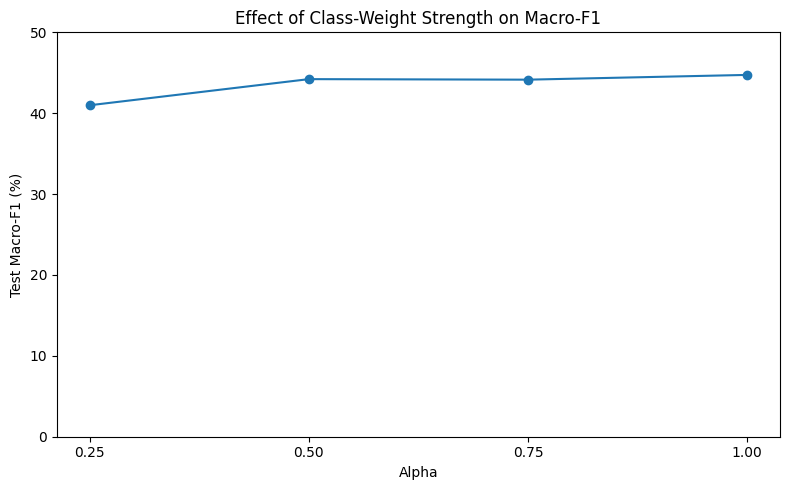

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    smoothed_results["alpha"],
    smoothed_results["Macro-F1"],
    marker="o",
)

plt.title("Effect of Class-Weight Strength on Macro-F1")
plt.xlabel("Alpha")
plt.ylabel("Test Macro-F1 (%)")

plt.xticks(smoothed_results["alpha"])
plt.ylim(0, 50)

plt.tight_layout()
plt.show()

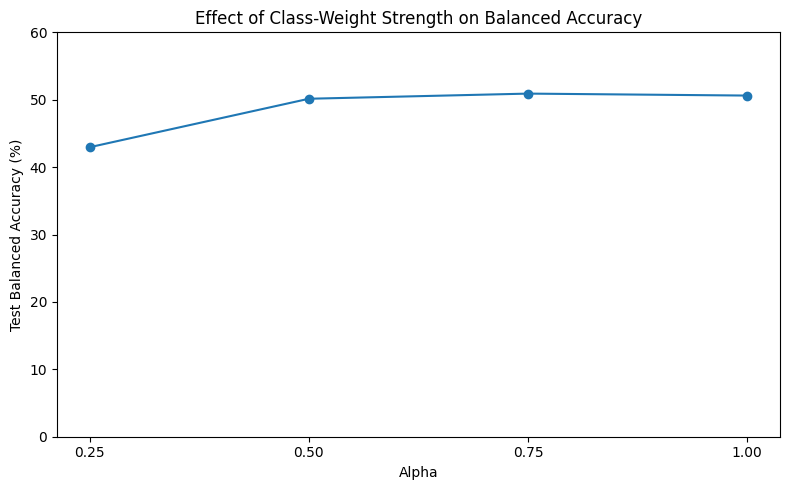

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    smoothed_results["alpha"],
    smoothed_results["Balanced Accuracy"],
    marker="o",
)

plt.title("Effect of Class-Weight Strength on Balanced Accuracy")
plt.xlabel("Alpha")
plt.ylabel("Test Balanced Accuracy (%)")

plt.xticks(smoothed_results["alpha"])
plt.ylim(0, 60)

plt.tight_layout()
plt.show()

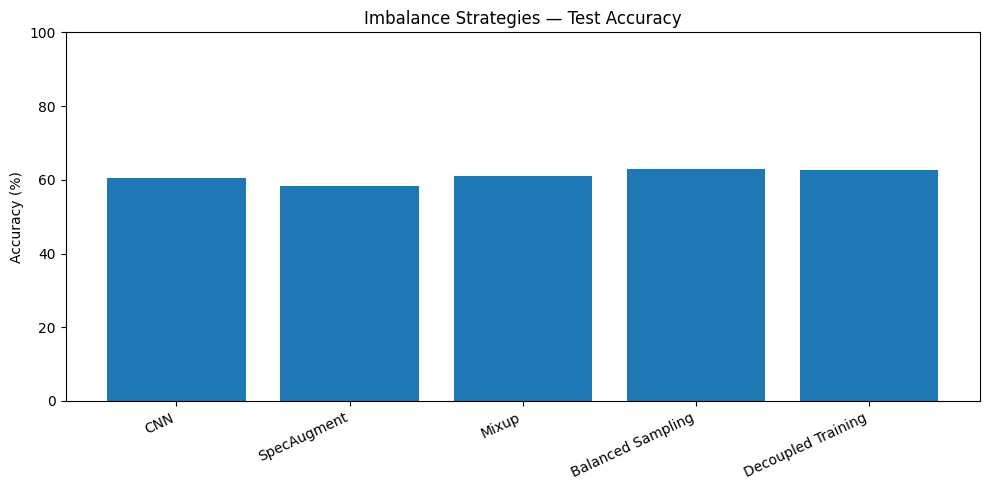

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    main_comparison_percent.index,
    main_comparison_percent["Accuracy"],
)

plt.title("Imbalance Strategies — Test Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

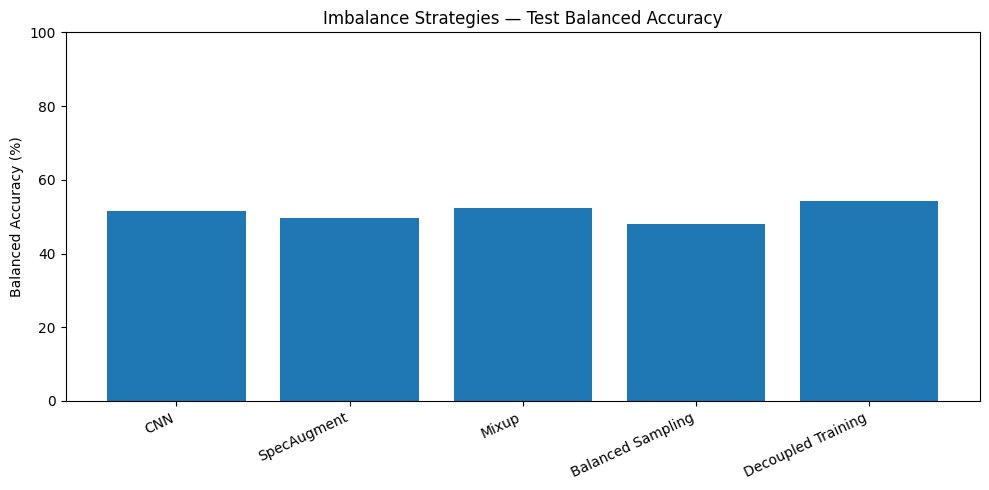

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(
    main_comparison_percent.index,
    main_comparison_percent["Balanced Accuracy"],
)

plt.title("Imbalance Strategies — Test Balanced Accuracy")
plt.ylabel("Balanced Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

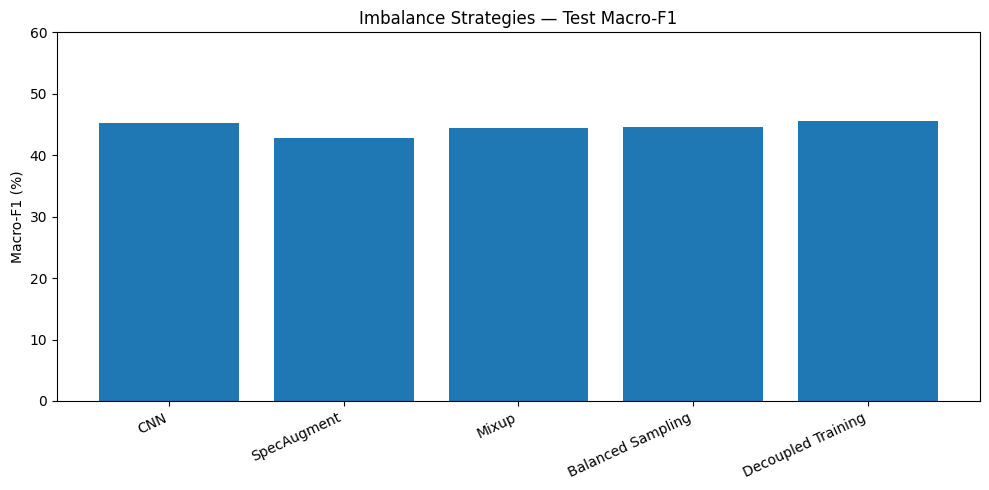

In [22]:
plt.figure(figsize=(10, 5))

plt.bar(
    main_comparison_percent.index,
    main_comparison_percent["Macro-F1"],
)

plt.title("Imbalance Strategies — Test Macro-F1")
plt.ylabel("Macro-F1 (%)")
plt.ylim(0, 60)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

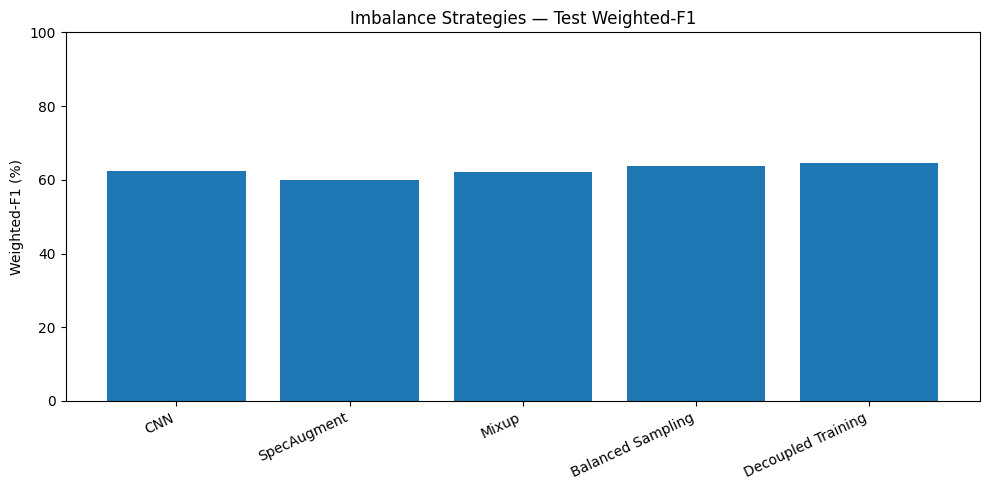

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    main_comparison_percent.index,
    main_comparison_percent["Weighted-F1"],
)

plt.title("Imbalance Strategies — Test Weighted-F1")
plt.ylabel("Weighted-F1 (%)")
plt.ylim(0, 100)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [24]:
cnn_reference = main_comparison_percent.loc["CNN"]

improvement = (
    main_comparison_percent - cnn_reference
).drop(index="CNN")

improvement.round(2)

,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
SpecAugment,-2.41,-2.08,-2.49,-2.36
Mixup,0.31,0.87,-0.88,-0.20
Balanced Sampling,2.18,-3.64,-0.75,1.38
Decoupled Training,1.91,2.79,0.37,2.07


In [25]:
decoupled_comparison = pd.DataFrame({
    "CNN": main_comparison_percent.loc["CNN"],
    "Decoupled Training": main_comparison_percent.loc["Decoupled Training"],
})

decoupled_comparison.round(2)

,CNN,Decoupled Training
Accuracy,60.61,62.52
Balanced Accuracy,51.58,54.37
Macro-F1,45.27,45.65
Weighted-F1,62.43,64.50


In [26]:
decoupled_improvement = (
    main_comparison_percent.loc["Decoupled Training"]
    - main_comparison_percent.loc["CNN"]
)

decoupled_improvement.round(2)

Accuracy             1.91
Balanced Accuracy    2.79
Macro-F1             0.37
Weighted-F1          2.07
dtype: float64

## Observations

### Smoothed class weights

Changing the class-weight exponent produces different trade-offs.

- α = 0.25 gives the highest accuracy among the tested configurations.
- α = 0.75 gives the highest balanced accuracy.
- α = 1.00 gives the highest Macro-F1.
- None of the tested values improves all four metrics over the original CNN.

### SpecAugment

The evaluated SpecAugment configuration performs below the CNN baseline on all four test metrics.

### Mixup

Mixup slightly improves accuracy and balanced accuracy, but Macro-F1 and weighted-F1 are lower than the CNN baseline.

### Focal Loss

The tested Focal Loss configurations do not outperform the CNN baseline.

### Balanced Sampling

Balanced Sampling improves accuracy and weighted-F1, but balanced accuracy and Macro-F1 are lower than the CNN baseline.

### Decoupled Training

Decoupled Training improves all four test metrics relative to the CNN:

- Accuracy: +1.91 percentage points
- Balanced Accuracy: +2.79 percentage points
- Macro-F1: +0.38 percentage points
- Weighted-F1: +2.07 percentage points

In [28]:
main_comparison_percent.round(4).to_csv(
    METRICS_DIR / "imbalance_strategy_comparison.csv"
)